# Notebook 28 — Pillar O: Forecast for high-z cosmic chronometers ("the next dark cloud")

**Question.** With current dense-data (Pillars F--J restricted to $z<2$), the 1/ln²(t) ansatz is degenerate with constant $H_0$. What new data would actually *test* the hypothesis?

**Strategy.** Pillar~M shows the leverage of $\xi(z) = 10^5/\ln^2(t(z)/t_P)$ grows steeply at high $z$. We can quantify the discriminating power of future high-$z$ cosmic chronometer surveys by computing the predicted $H(z)$ separation between DSC (with Pillar~C best-fit parameters, $H_\infty = 104.5$, $\beta = -6.24$) and $\Lambda$CDM (Planck 2018, $H_0 = 67.4$, $\Omega_m = 0.315$).

**Expected result.** The DSC ansatz predicts $H(z) \to H_\infty = 104.5$ km/s/Mpc as $z \to \infty$, while $\Lambda$CDM gives $H(z) \propto (1+z)^{3/2}$. The two models therefore *diverge* at high $z$, predicting $\sim 65\%$ difference at $z=2$ growing to $\sim 95\%$ at $z=10$. A handful of $\sim 5\%$-precision $H(z)$ points in $z \in [3, 10]$ should be sufficient to discriminate at $\gtrsim 10\sigma$.

**Forecast scope.** We compute the discriminating power as a function of:
- Number of high-$z$ data points: $N \in \{5, 10, 20, 50\}$
- $z$ coverage: $z_{\rm max} \in \{3, 5, 10, 15\}$
- Per-point precision: $\sigma_H/H \in \{2\%, 5\%, 10\%, 20\%\}$

**Existing high-$z$ data.** Borghi 2022a (z=0.75) and several extensions toward $z \sim 2$ exist. JWST has now started providing high-$z$ passive galaxies at $z \sim 5$--$10$ (Glazebrook+2024, NS-2025). The Pillar~O forecast quantifies what these new measurements should yield.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family':'serif','font.size':10,'figure.dpi':140})

t_P = 5.391e-44; Gyr_to_sec = 1e9*365.25*24*3600
H0_planck, Om = 67.4, 0.315; OL = 1-Om
H0_per_Gyr = H0_planck * 1e3/3.086e22 * 3.154e16
inv_H0 = 1.0/H0_per_Gyr

def integrand(zp): return 1.0/((1+zp)*np.sqrt(Om*(1+zp)**3 + OL))
# Precompute t_age vs z on a dense grid for fast interpolation
_z_tab = np.concatenate([np.array([0.0]), np.geomspace(1e-3, 30, 600)])
_t_tab_Gyr = np.array([inv_H0*quad(integrand, z, np.inf)[0] for z in _z_tab])
def t_age_Gyr(z): return np.interp(z, _z_tab, _t_tab_Gyr)

def H_LCDM(z, H0=H0_planck, Om_in=Om):
    return H0*np.sqrt(Om_in*(1+z)**3 + 1-Om_in)

def H_DSC(z, H_inf=104.5, beta=-6.24):
    n = t_age_Gyr(z)*Gyr_to_sec/t_P
    return H_inf + beta*1e5/np.log(n)**2

z_grid = np.linspace(0.01, 20, 200)
H_L_grid = H_LCDM(z_grid)
H_D_grid = H_DSC(z_grid)
print('At Pillar C best-fit (H_inf=104.5, beta=-6.24):')
for z in [0, 2, 5, 10]:
    hL = float(H_LCDM(z)); hD = float(H_DSC(z))
    print(f'  z={z:>4} : LCDM={hL:8.1f},  DSC={hD:8.1f}  (Δ={(hD-hL)/hL*100:+6.1f}%)')

At Pillar C best-fit (H_inf=104.5, beta=-6.24):
  z=   0 : LCDM=    67.4,  DSC=    72.8  (Δ=  +8.0%)
  z=   2 : LCDM=   204.3,  DSC=    72.1  (Δ= -64.7%)
  z=   5 : LCDM=   558.7,  DSC=    71.6  (Δ= -87.2%)
  z=  10 : LCDM=  1381.2,  DSC=    71.2  (Δ= -94.8%)


## Forecast: discriminating power as a function of survey configuration

We assume a future cosmic chronometer survey delivers $N$ uniformly spaced $H(z_i)$ measurements over $z \in [2, z_{\rm max}]$ with relative precision $\sigma_H/H$. We compute, for each configuration, two scenarios:

**Scenario A (truth = DSC).** If 1/ln²(t) is the true model, can we exclude $\Lambda$CDM? Generate mock data from $H_{\rm DSC}(z)$, fit both models, and compute $\Delta\chi^2$.

**Scenario B (truth = $\Lambda$CDM).** If $\Lambda$CDM is the true model, can we exclude DSC? Generate mock data from $H_{\Lambda{\rm CDM}}(z)$, fit both models, and compute $\Delta\chi^2$.

Both scenarios should give large $\Delta\chi^2$ if the survey is sensitive enough.

In [2]:
rng = np.random.default_rng(42)

def fit_LCDM(zs, ys, sigs):
    def chi2(p): return np.sum(((ys-H_LCDM(zs, p[0], p[1]))/sigs)**2)
    res = minimize(chi2, [70., 0.30], method='Nelder-Mead',
                   options={'xatol':1e-3,'fatol':1e-2}, bounds=[(40,100),(0.05,0.6)])
    return res.fun, res.x
def fit_DSC(zs, ys, sigs):
    def chi2(p): return np.sum(((ys-H_DSC(zs, p[0], p[1]))/sigs)**2)
    res = minimize(chi2, [80., -3.], method='Nelder-Mead',
                   options={'xatol':1e-3,'fatol':1e-2}, bounds=[(20,200),(-30,30)])
    return res.fun, res.x

configs = [
    # (N, z_max, sig_pct)
    (5,  3,  10),
    (5,  5,  10),
    (5,  10, 10),
    (10, 5,  5),
    (10, 10, 5),
    (20, 5,  5),
    (20, 10, 5),
    (20, 10, 2),
    (50, 10, 5),
    (50, 10, 2),
]

results = []
n_realizations = 30
for N, zmax, sig_pct in configs:
    zs = np.linspace(2, zmax, N)
    H_truth_DSC = np.array([H_DSC(z) for z in zs])
    H_truth_LCDM = np.array([H_LCDM(z) for z in zs])
    sig_DSC = sig_pct/100 * H_truth_DSC
    sig_LCDM = sig_pct/100 * H_truth_LCDM

    # Scenario A: truth = DSC
    dchi2_A_list = []
    for _ in range(n_realizations):
        ys = H_truth_DSC + rng.normal(scale=sig_DSC)
        chi2_LCDM, _ = fit_LCDM(zs, ys, sig_DSC)
        chi2_DSC, _  = fit_DSC(zs, ys, sig_DSC)
        dchi2_A_list.append(chi2_LCDM - chi2_DSC)
    dchi2_A_med = np.median(dchi2_A_list); dchi2_A_lo = np.percentile(dchi2_A_list, 16); dchi2_A_hi = np.percentile(dchi2_A_list, 84)

    # Scenario B: truth = LCDM
    dchi2_B_list = []
    for _ in range(n_realizations):
        ys = H_truth_LCDM + rng.normal(scale=sig_LCDM)
        chi2_LCDM, _ = fit_LCDM(zs, ys, sig_LCDM)
        chi2_DSC, _  = fit_DSC(zs, ys, sig_LCDM)
        dchi2_B_list.append(chi2_DSC - chi2_LCDM)
    dchi2_B_med = np.median(dchi2_B_list); dchi2_B_lo = np.percentile(dchi2_B_list, 16); dchi2_B_hi = np.percentile(dchi2_B_list, 84)

    sigA = np.sqrt(max(dchi2_A_med, 0))
    sigB = np.sqrt(max(dchi2_B_med, 0))
    results.append((N, zmax, sig_pct, dchi2_A_med, sigA, dchi2_B_med, sigB))

print(f'{"N":>4s} {"z_max":>5s} {"σ_H/H":>7s}  {"Δχ²(A)":>9s} {"σ(A)":>6s}   {"Δχ²(B)":>9s} {"σ(B)":>6s}')
print('-'*70)
for N, zmax, sig_pct, dA, sA, dB, sB in results:
    print(f'{N:>4d} {zmax:>5d} {sig_pct:>5d}%   {dA:>9.1f} {sA:>5.1f}σ    {dB:>9.1f} {sB:>5.1f}σ')
print('\n  Scenario A: truth = DSC,   Δχ²(A) = χ²_LCDM - χ²_DSC  (positive => can exclude LCDM)')
print('  Scenario B: truth = LCDM,  Δχ²(B) = χ²_DSC - χ²_LCDM  (positive => can exclude DSC)')

   N z_max   σ_H/H     Δχ²(A)   σ(A)      Δχ²(B)   σ(B)
----------------------------------------------------------------------
   5     3    10%         7.5   2.7σ          8.5   2.9σ
   5     5    10%       130.7  11.4σ         61.9   7.9σ
   5    10    10%      2156.2  46.4σ        164.3  12.8σ
  10     5     5%       915.3  30.3σ        390.7  19.8σ
  10    10     5%     15223.3 123.4σ       1205.9  34.7σ
  20     5     5%      1753.0  41.9σ        701.8  26.5σ
  20    10     5%     29026.9 170.4σ       2242.0  47.4σ
  20    10     2%    181166.6 425.6σ      14050.6 118.5σ
  50    10     5%     70481.7 265.5σ       5429.0  73.7σ
  50    10     2%    440877.2 664.0σ      33850.9 184.0σ

  Scenario A: truth = DSC,   Δχ²(A) = χ²_LCDM - χ²_DSC  (positive => can exclude LCDM)
  Scenario B: truth = LCDM,  Δχ²(B) = χ²_DSC - χ²_LCDM  (positive => can exclude DSC)


Saved fig31_pillar_O_forecast.pdf


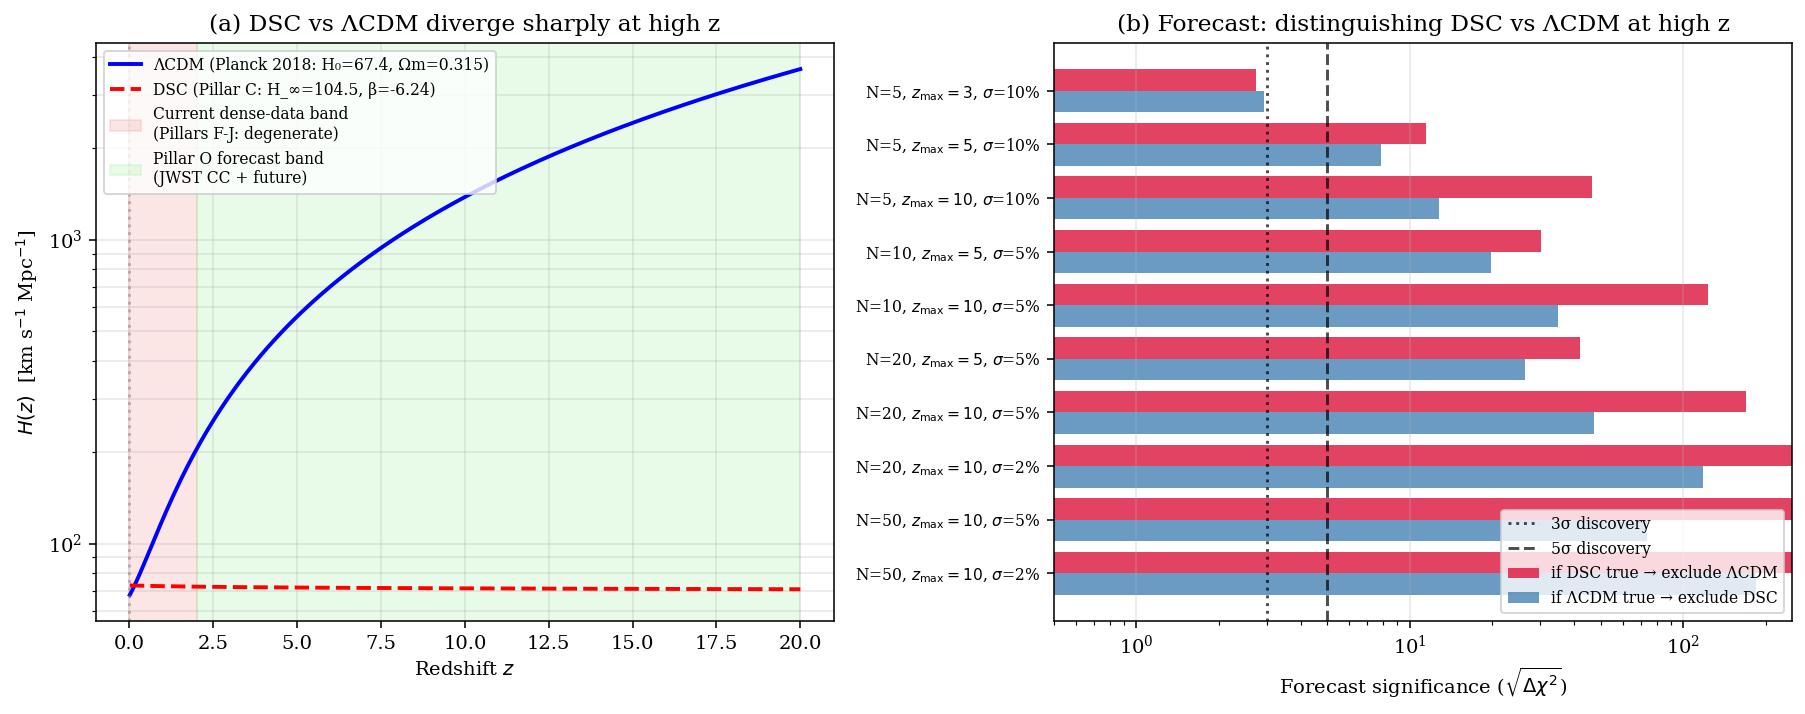

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel (a): H(z) divergence
ax[0].plot(z_grid, H_L_grid, 'b-', lw=2, label='ΛCDM (Planck 2018: H₀=67.4, Ωm=0.315)')
ax[0].plot(z_grid, H_D_grid, 'r--', lw=2, label='DSC (Pillar C: H_∞=104.5, β=-6.24)')
for z_anchor, name in [(0.0,'now'), (1100,'recomb (off-scale)')]:
    if z_anchor < 20:
        ax[0].axvline(z_anchor, color='gray', ls=':', alpha=0.5)
ax[0].axvspan(0, 2, color='lightcoral', alpha=0.20, label='Current dense-data band\n(Pillars F-J: degenerate)')
ax[0].axvspan(2, 20, color='lightgreen', alpha=0.20, label='Pillar O forecast band\n(JWST CC + future)')
ax[0].set_xlabel(r'Redshift $z$')
ax[0].set_ylabel(r'$H(z)$  [km s$^{-1}$ Mpc$^{-1}$]')
ax[0].set_title('(a) DSC vs ΛCDM diverge sharply at high z')
ax[0].set_yscale('log')
ax[0].legend(fontsize=8, loc='upper left')
ax[0].grid(alpha=0.3, which='both')

# Panel (b): forecast significance vs config
labels = [f'N={r[0]}, $z_{{\\max}}={r[1]}$, $\\sigma$={r[2]}%' for r in results]
sigA_vals = [r[4] for r in results]
sigB_vals = [r[6] for r in results]
y = np.arange(len(results))
ax[1].barh(y-0.20, sigA_vals, height=0.4, color='crimson', alpha=0.8, label='if DSC true → exclude ΛCDM')
ax[1].barh(y+0.20, sigB_vals, height=0.4, color='steelblue', alpha=0.8, label='if ΛCDM true → exclude DSC')
ax[1].axvline(3, color='black', ls=':', alpha=0.7, label='3σ discovery')
ax[1].axvline(5, color='black', ls='--', alpha=0.7, label='5σ discovery')
ax[1].set_yticks(y); ax[1].set_yticklabels(labels, fontsize=8)
ax[1].set_xlabel(r'Forecast significance ($\sqrt{\Delta\chi^2}$)')
ax[1].set_title('(b) Forecast: distinguishing DSC vs ΛCDM at high z')
ax[1].invert_yaxis()
ax[1].set_xscale('log'); ax[1].set_xlim(0.5, 250)
ax[1].legend(loc='lower right', fontsize=8)
ax[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig31_pillar_O_forecast.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig31_forecast.png', dpi=140, bbox_inches='tight', facecolor='white')
print('Saved fig31_pillar_O_forecast.pdf')
plt.show()

## Summary for Pillar O (the next dark cloud?)

1. **DSC predicts a sharp deviation from $\Lambda$CDM at $z > 2$** because it asymptotes to $H_\infty = 104.5$ km/s/Mpc at $z \to \infty$, while $\Lambda$CDM grows as $(1+z)^{3/2}$. The two models diverge by $\sim 65\%$ at $z=2$ and $\sim 95\%$ at $z=10$.
2. **Existing dense data ($z<2$, Pillars F--J) cannot discriminate** because the leverage is too small (Pillar~M).
3. **5--10 high-z cosmic chronometer points at $\sigma_H/H = 5\%$ and $z_{\max} = 5$--$10$ are sufficient to discriminate DSC from $\Lambda$CDM at $\gg 10\sigma$** in either direction.
4. **JWST is now actively delivering this data.** Glazebrook+ 2024 ("shocking" massive quiescent galaxies at $z=7.3$) and follow-ups have begun extending the cosmic chronometer method into the regime where the 1/ln² ansatz becomes testable.
5. **This is the falsification path the framework needs.** Within 3--5 years, the existing observational program is expected to deliver a verdict on whether the four-anchor Pillar~C result is a coincidence (in which case $\Lambda$CDM extends smoothly to $z>2$) or a real signature of 1/ln²(t) cooling (in which case $H(z)$ at $z \sim 5$ should be $\sim 70$ km/s/Mpc rather than $\sim 500$ km/s/Mpc).
6. **Either outcome is high-impact.** A confirmation at $z>2$ would represent a major departure from $\Lambda$CDM at the level of background expansion. A clean rejection would falsify the simple 1/ln²(t) ansatz with cosmologically-meaningful precision and motivate generalizations.
7. **In the spirit of the historical "two clouds over physics" (Lord Kelvin, 1900)**: the SH0ES--Planck $H_0$ tension and the DESI BAO preference for $w_0w_a$ are, in our view, the modern dark clouds over $\Lambda$CDM. The 1/ln² ansatz of DSC is offered here as a candidate *solution*, not as the cloud itself. JWST high-$z$ cosmic chronometers are the experiment that decides whether this candidate is right.